In [3]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import warnings
warnings.filterwarnings('ignore')

In [4]:
def expected_improvement(X, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0
    return ei

In [5]:
def propose_next_point(X_obs, y_obs, bounds, n_candidates=5000):
    """
    X_obs: (N, D)
    y_obs: (N,)
    bounds: list of (min, max) for each dimension → length D
    """

    dim = X_obs.shape[1]

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidate points in D dimensions
    X_candidates = np.random.uniform(
        low=[b[0] for b in bounds],
        high=[b[1] for b in bounds],
        size=(n_candidates, dim)
    )
    y_best = np.max(y_obs)
    ei = expected_improvement(X_candidates, gp, y_best)

    return X_candidates[np.argmax(ei)]

In [35]:
# np.random.seed(0)
# Example data
X_obs = np.load("f1initial_inputs.npy")
y_obs = np.load("f1initial_outputs.npy")

bounds = [(0.0, 1.0), (0.0, 1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.28455092 0.66874421]


In [36]:
X_obs = np.load("f2initial_inputs.npy")
y_obs = np.load("f2initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

bounds = [(0.0, 1.0), (0.0, 1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

(10, 2) (10,)
Next query point: [0.94609085 0.12792525]


In [37]:
X_obs = np.load("f3initial_inputs.npy")
y_obs = np.load("f3initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(15, 3) (15,)


In [38]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.89059557 0.17511937 0.09880408]


In [39]:
X_obs = np.load("f4initial_inputs.npy")
y_obs = np.load("f4initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(30, 4) (30,)


In [40]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.27518212 0.65047752 0.83154399 0.04441951]


In [41]:
X_obs = np.load("f5initial_inputs.npy")
y_obs = np.load("f5initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(20, 4) (20,)


In [43]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.75817293 0.23237159 0.38423394 0.01592666]


In [44]:
X_obs = np.load("f6initial_inputs.npy")
y_obs = np.load("f6initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(20, 5) (20,)


In [45]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0), (0.0,1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.64629005 0.4797929  0.77303075 0.31361362 0.00639373]


In [46]:
X_obs = np.load("f7initial_inputs.npy")
y_obs = np.load("f7initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(30, 6) (30,)


In [47]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0), (0.0,1.0), (0.0,1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.72690321 0.73445472 0.20731692 0.18504647 0.33438664 0.73999152]


In [6]:
X_obs = np.load("f8initial_inputs.npy")
y_obs = np.load("f8initial_outputs.npy")
print(X_obs.shape, y_obs.shape)

(40, 8) (40,)


In [50]:
bounds = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0), (0.0,1.0), (0.0,1.0), (0.0,1.0),(0.0,1.0)]

x_next = propose_next_point(X_obs, y_obs, bounds)

print("Next query point:", x_next)

Next query point: [0.13026556 0.0462832  0.17283902 0.19456194 0.98843787 0.43200024
 0.22214739 0.76142263]


In [7]:
print(X_obs[1])

[0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
 0.63538449 0.10713163]


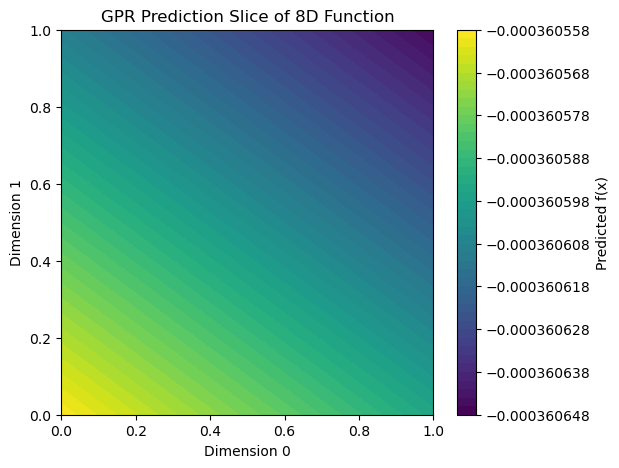

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF


# Training data (100 points in 8D)
X_train = np.load("f1initial_inputs.npy")
y_train = np.load("f1initial_outputs.npy")

# Fit GPR
kernel = RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6)
gpr.fit(X_train, y_train)

# Choose two dimensions to vary for plotting
dim1, dim2 = 0, 1
grid_size = 50

# Create a grid for the two dimensions
x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)
X1, X2 = np.meshgrid(x1, x2)

# Prepare 8D input array for prediction, fix other dims at 0.5
X_plot = np.ones((grid_size * grid_size, 2)) * 0.5
X_plot[:, dim1] = X1.ravel()
X_plot[:, dim2] = X2.ravel()

# Predict with GPR
y_pred, y_std = gpr.predict(X_plot, return_std=True)
Y_pred = y_pred.reshape(grid_size, grid_size)

# Plot 2D heatmap
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Y_pred, cmap='viridis', levels=50)
plt.colorbar(label='Predicted f(x)')
plt.xlabel(f'Dimension {dim1}')
plt.ylabel(f'Dimension {dim2}')
plt.title('GPR Prediction Slice of 8D Function')
plt.show()